<div style='text-align:center; fontsize=50px'>
    <h1>DR1 Detailed Evolution</h1>
    <p>Let's explore a likely system</p>
</div>

In [1]:
import backpop
from backpop import BackPopsteriors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const
import matplotlib as mpl

pd.set_option('display.max_columns', None)

import sys
sys.path.append("../helpers")
import corners

import cosmic
from cosmic.sample import InitialBinaryTable
from cosmic.evolve import Evolve
from cosmic.utils import parse_inifile
import cogsworth

fs = 24
style_params = {
    'font.family': 'serif',
    'text.usetex': False,
    'figure.figsize': (12, 8),
    'axes.titlesize': 24,
    'legend.title_fontsize': 18,
    'legend.fontsize': 16,
    'axes.labelsize': 24,
    'xtick.labelsize': 21,
    'ytick.labelsize': 21,
    'axes.linewidth': 1.1,
    'xtick.major.size': 7,
    'xtick.minor.size': 4,
    'ytick.major.size': 7,
    'ytick.minor.size': 4,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
}
plt.rcParams.update(style_params)

%config InlineBackend.figure_format = 'retina'

In [29]:
kstar_colours = [k["colour"] for k in cogsworth.utils.kstar_translator]
kstar_colours[-2] = "white"
kstar_labels = [k["short"].replace("HeHG", "HeSB") for k in cogsworth.utils.kstar_translator]
BSEDict, SSEDict, seed_int, filters, convergence, sampling = parse_inifile("../helpers/params.ini")

In [3]:
p = corners.prepare_posteriors_for_corner(
    BackPopsteriors(file="/mnt/home/twagg/ceph/dr1/ejection/posteriors.h5",
                    var_labels=np.array([r"$m_{1, i}$ [M$_\odot$]", r"$m_{2, i}$ [M$_\odot$]", r"$\log_{\rm 10}(P_i / {\rm days})$",
                                         r"$e_i$", r"$v_{\rm kick}$ [km/s]", r"$\phi_{\rm kick}$ [rad]",
                                         r"$\theta_{\rm kick}$ [rad]", r"$\omega$ [rad]"])),
)

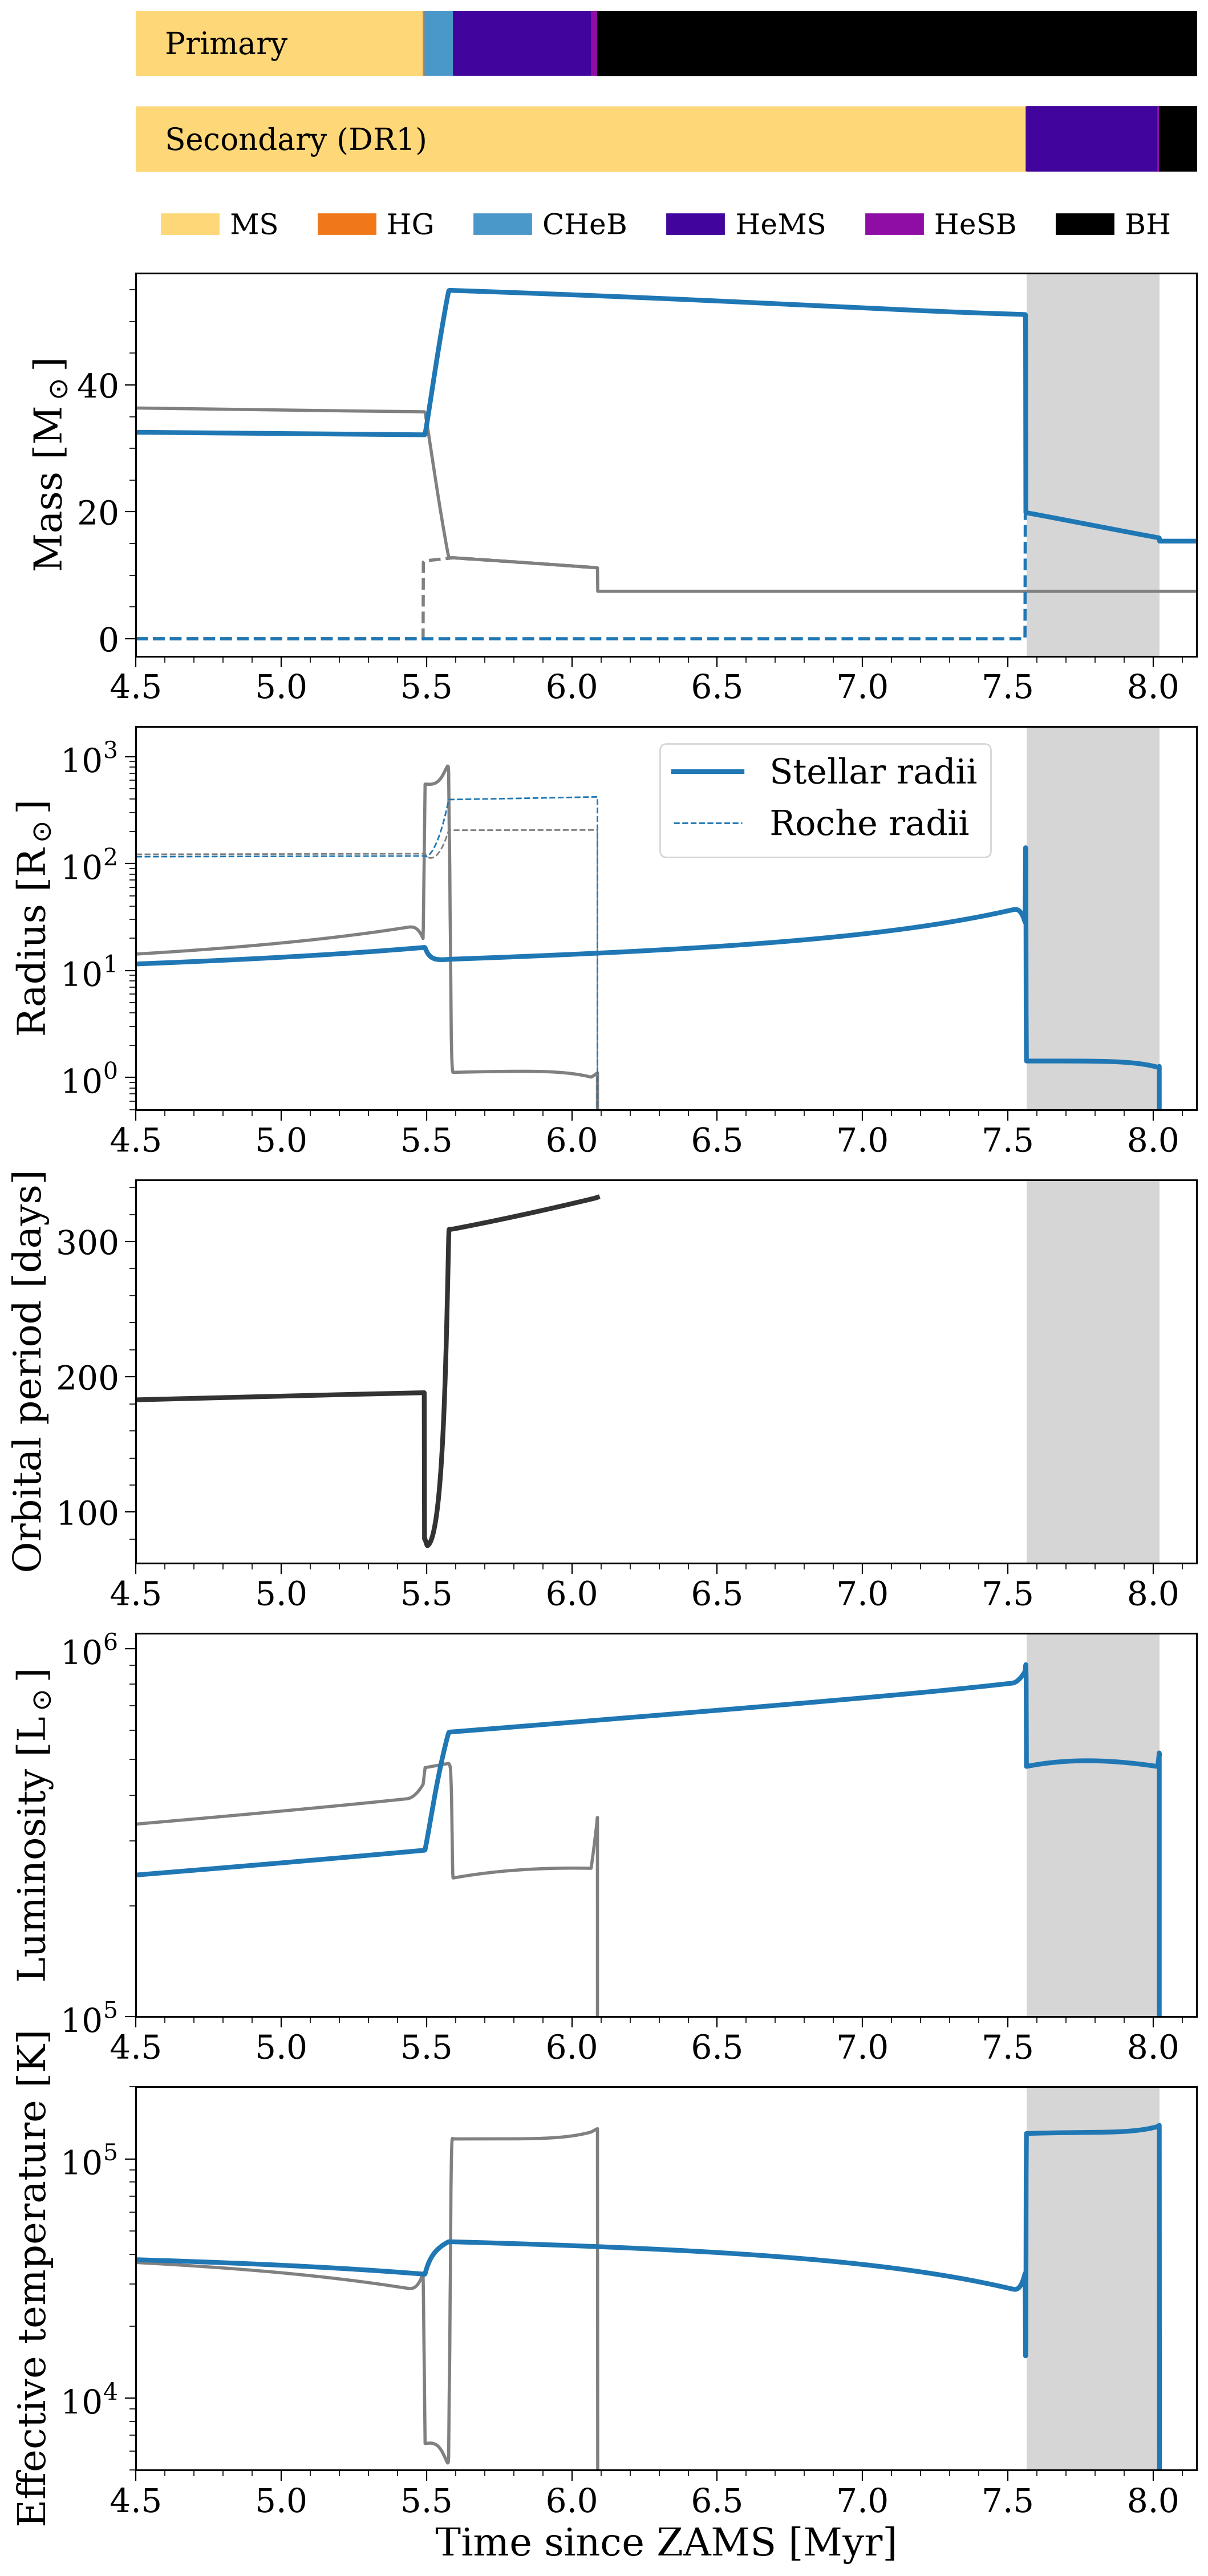

In [4]:
# for ex_ind, example in enumerate(examples):
examples = p.bcm_row.iloc[np.argsort(p.log_l)[-5:]]["bin_num"].values
example = examples[-1]

initC = p.bpp.loc[example].iloc[[0]]
ibt = InitialBinaryTable.InitialBinaries(
    m1=initC["mass_1"].values[0],
    m2=initC["mass_2"].values[0],
    porb=initC["porb"].values[0],
    ecc=initC["ecc"].values[0],
    tphysf=8.5,
    metallicity=0.00284,
    kstar1=initC["kstar_1"].values[0],
    kstar2=initC["kstar_2"].values[0]
) 
ibt["randomseed"] = 1816656225
BSEDict["natal_kick_array"] = np.array([[500.0, -100.0, -100.0, -100.0, 0],
                                        [-100.0, -100.0, -100.0, -100.0, 0]])
_, bcm, initC, _ = Evolve.evolve(ibt, BSEDict=BSEDict, SSEDict=SSEDict, dtp=0.001)

t_min = 4.5
t_max = 8.15

masked_bcm = bcm[(bcm["tphys"] > t_min) & (bcm["tphys"] < t_max)]

primary_kwargs = {
    "color": "grey",
    "lw": 2
}
secondary_kwargs = {
    "color": "tab:blue",
    "lw": 3
}

dr1_rows = bcm[bcm["kstar_2"].isin([1, 7, 8]) & (bcm["teff_2"] > 100_000)]

fig, axes = plt.subplots(6, 1, figsize=(12, 28), gridspec_kw={"height_ratios": [2, 4, 4, 4, 4, 4]})

axes[0].axis("off")

pos = axes[0].get_position()
new_pos = [pos.x0, pos.y0 - 0.02, pos.width, pos.height + 0.02]
axes[0].set_position(new_pos)

for j, k in enumerate(np.unique(masked_bcm["kstar_1"])):
    axes[0].fill_between(masked_bcm["tphys"][masked_bcm["kstar_1"] == k], 0.7, 0.9, color=kstar_colours[k])
for j, k in enumerate(np.unique(masked_bcm["kstar_2"])):
    axes[0].fill_between(masked_bcm["tphys"][masked_bcm["kstar_2"] == k], 0.4, 0.6, color=kstar_colours[k])

axes[0].annotate("Primary", xy=(4.6, 0.79), xycoords="data", fontsize=0.8*fs, ha="left", va="center")
axes[0].annotate("Secondary (DR1)", xy=(4.6, 0.49), xycoords="data", fontsize=0.8*fs, ha="left", va="center")

axes[0].set_ylim(0.1, 0.9)

k_type_all = np.unique(np.array([masked_bcm["kstar_1"], masked_bcm["kstar_2"]]))
patches = [
    mpl.patches.Patch(color=kstar_colours[k], label=kstar_labels[k]) for k in k_type_all
]
leg = axes[0].legend(handles=patches, mode="expand", ncol=len(k_type_all), frameon=False, fontsize=0.75*fs, handletextpad=0.4)

ax_mass = axes[1]
ax_rad = axes[2]
ax_porb = axes[3]
ax_lum = axes[4]
ax_teff = axes[5]

for suffix, kwargs in zip(["_1", "_2"], [primary_kwargs, secondary_kwargs]):
    
    ax_mass.plot(masked_bcm["tphys"], masked_bcm[f"mass{suffix}"], **kwargs)
    ax_mass.plot(masked_bcm["tphys"][masked_bcm[f"kstar{suffix}"] < 10],
                 (masked_bcm[f"massc_he_layer{suffix}"] + masked_bcm[f"massc_co_layer{suffix}"])[masked_bcm[f"kstar{suffix}"] < 10],
                 lw=2, color=kwargs["color"], linestyle='--')

    opposite = "_2" if suffix == "_1" else "_1"
    roche = cosmic.utils.calc_Roche_radius(masked_bcm[f"mass{suffix}"], masked_bcm[f"mass{opposite}"], masked_bcm["sep"] * (1.0 - masked_bcm["ecc"]))
    ax_rad.plot(masked_bcm["tphys"], masked_bcm[f"rad{suffix}"], **kwargs, label="Stellar radii" if suffix == "_2" else None)
    ax_rad.plot(masked_bcm["tphys"], roche, lw=1, color=kwargs["color"], linestyle="--", label="Roche radii" if suffix == "_2" else None)

    ax_lum.plot(masked_bcm["tphys"], masked_bcm[f"lum{suffix}"], **kwargs)

    ax_teff.plot(masked_bcm["tphys"], masked_bcm[f"teff{suffix}"], **kwargs)

ax_porb.plot(masked_bcm["tphys"][masked_bcm["porb"] > 0], masked_bcm["porb"][masked_bcm["porb"] > 0], color="#333", lw=3)

ax_mass.set_ylabel(r"Mass [M$_\odot$]")

ax_rad.legend(loc='upper center', fontsize=0.9*fs, frameon=True, bbox_to_anchor=(0.65, 1.0))
ax_rad.set(
    ylabel=r"Radius [R$_\odot$]",
    yscale="log",
    ylim=(5e-1, None)
)
ax_porb.set(
    ylabel=r"Orbital period [days]",
)

ax_lum.set(
    ylabel=r"Luminosity [L$_\odot$]",
    yscale="log",
    ylim=(1e5, 1.1e6)
)

ax_teff.set(
    ylabel=r"Effective temperature [K]",
    yscale="log",
    ylim=(5e3, 2e5)
)

for ax in axes:
    ax.set_xlim(t_min, t_max)

for ax in axes[1:]:
    ax.axvspan(dr1_rows["tphys"].min(), dr1_rows["tphys"].max(), color="#333", alpha=0.2, lw=0, label="DR1 window" if ax == axes[0] else None)

axes[-1].set_xlabel(r"Time since ZAMS [Myr]")

# axes[1].annotate("COSMIC", xy=(0.5, 0.5), xycoords="axes fraction", fontsize=0.8*fs, ha="center", va="center", color="#333")

# plt.savefig(f"../figures/backpop_detailed_example.pdf", bbox_inches="tight", dpi=300)
plt.show()

# Same for the merger channel

In [5]:
p = corners.prepare_posteriors_for_corner(
    BackPopsteriors(file="/mnt/home/twagg/ceph/dr1/gas_motions/posteriors.h5",
                    var_labels=np.array([r"$m_{1, i}$ [M$_\odot$]", r"$m_{2, i}$ [M$_\odot$]", r"$\log_{\rm 10}(P_i / {\rm days})$",
                                         r"$e_i$", r"$v_{\rm kick}$ [km/s]", r"$\phi_{\rm kick}$ [rad]",
                                         r"$\theta_{\rm kick}$ [rad]", r"$\omega$ [rad]"])),
)
bpp_start = p.bpp.drop_duplicates(subset="bin_num", keep="first")
RLOF_at_ZAMS = (bpp_start["RRLO_1"] >= 1) | (bpp_start["RRLO_2"] >= 1)
p.log_l[np.isfinite(p.log_l)] = np.where(RLOF_at_ZAMS, -np.inf, p.log_l[np.isfinite(p.log_l)])

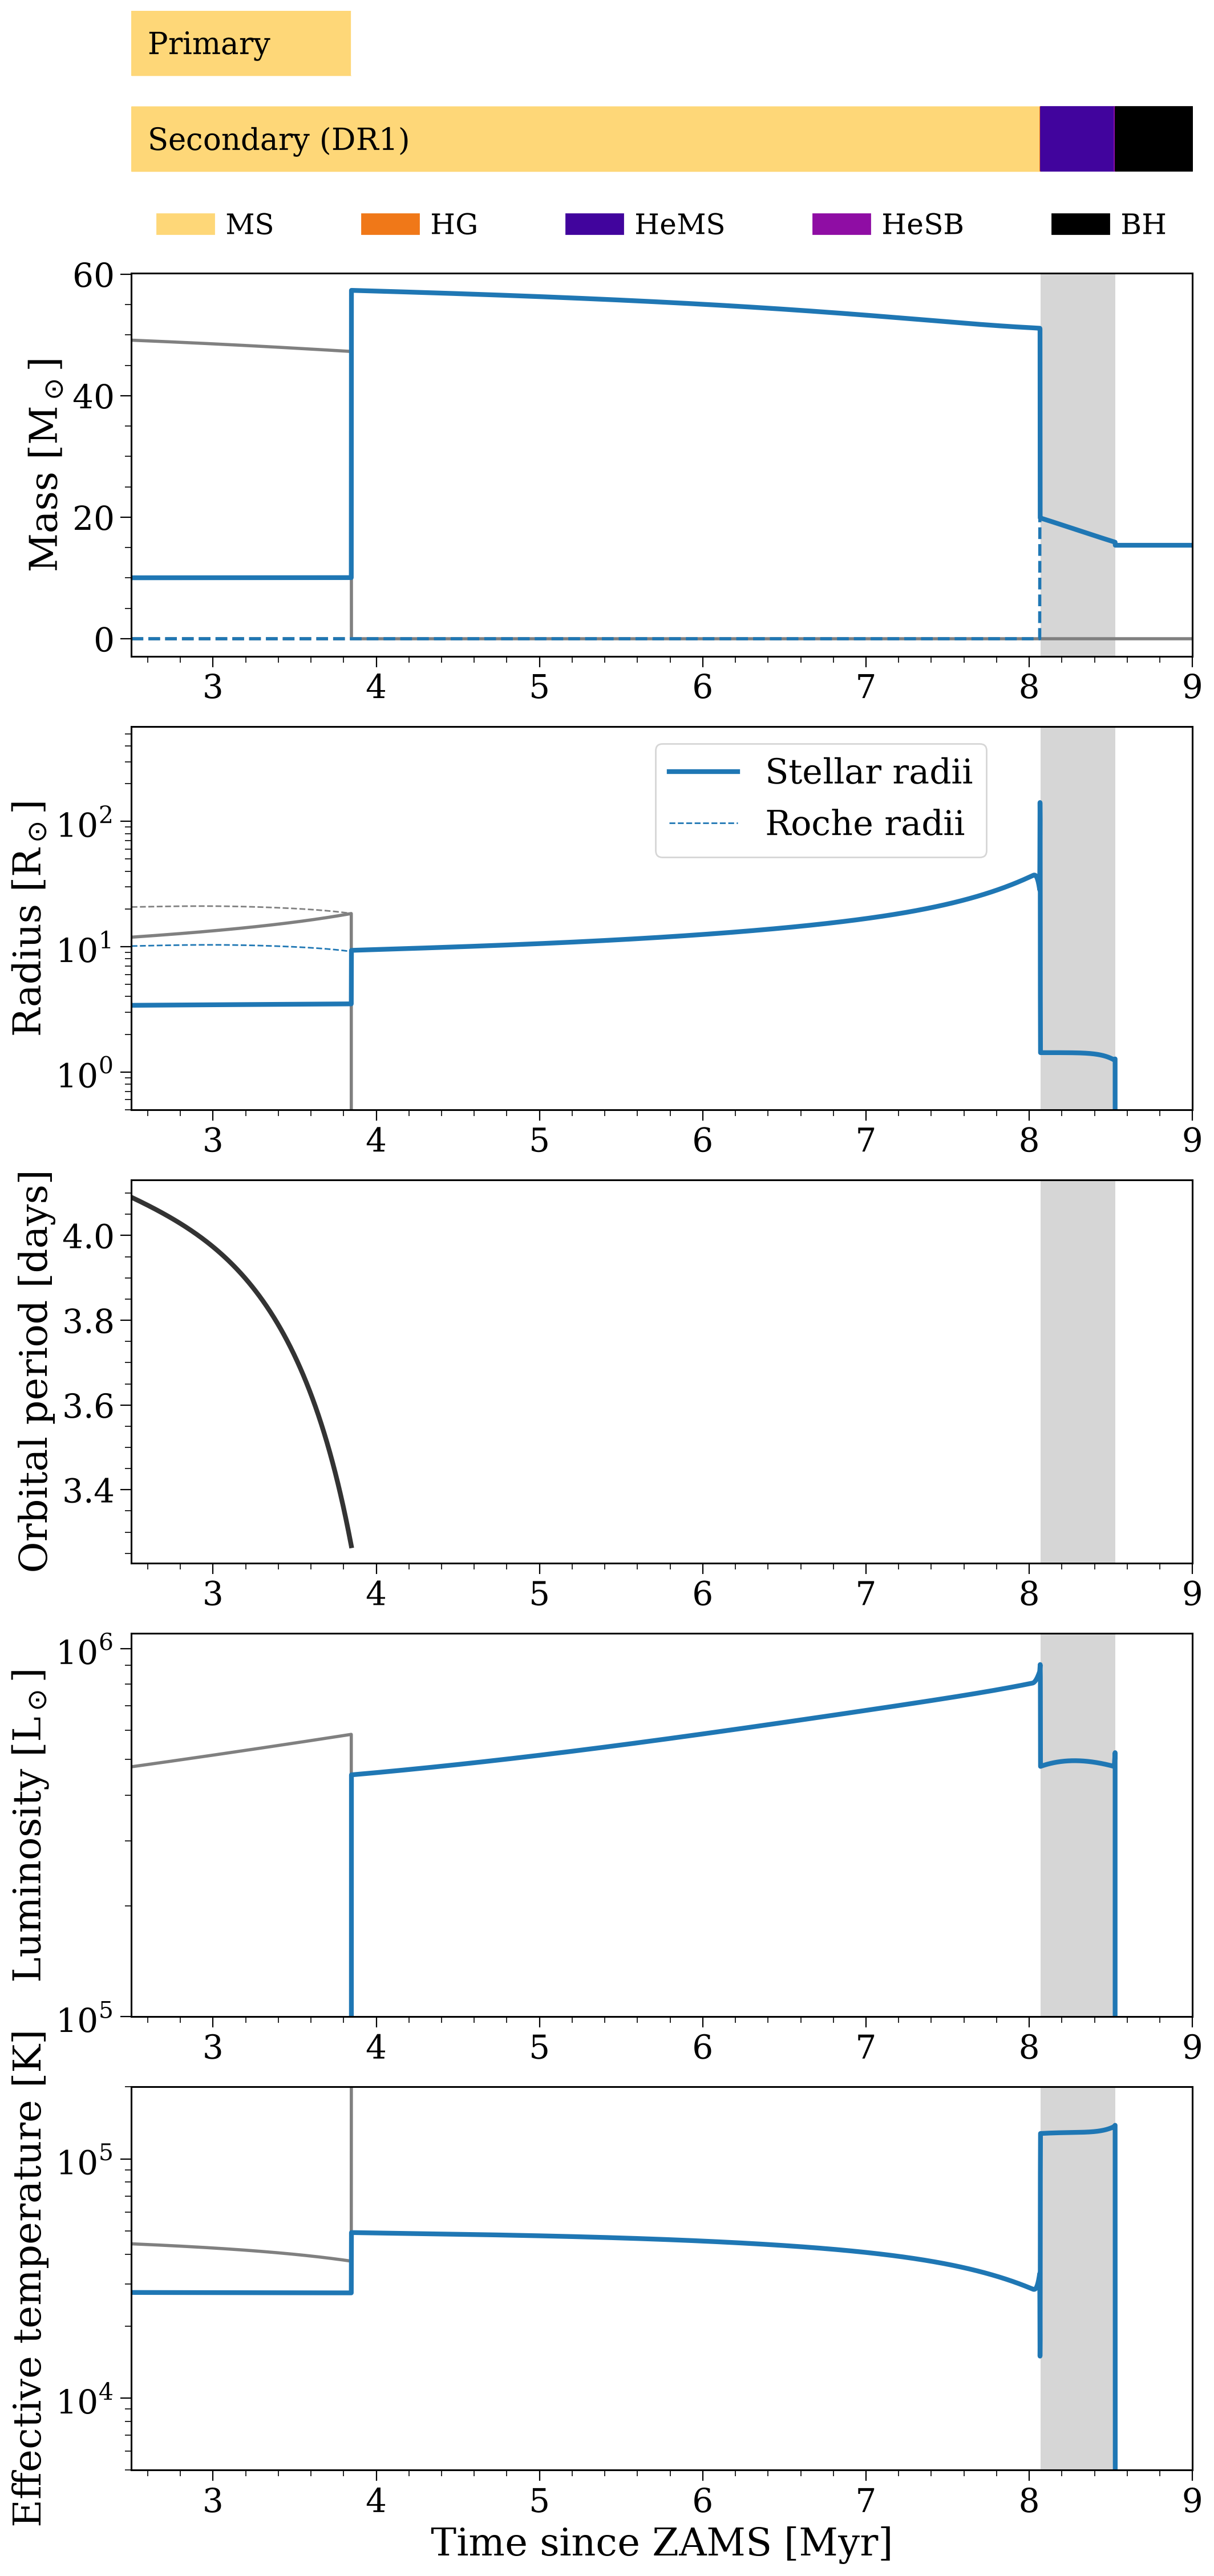

In [33]:
# for ex_ind, example in enumerate(examples):
examples = p.bcm_row.iloc[np.argsort(p.log_l)[-50:]]["bin_num"].values
example = examples[-7]

initC = p.bpp.loc[example].iloc[[0]]
ibt = InitialBinaryTable.InitialBinaries(
    m1=initC["mass_1"].values[0],
    m2=initC["mass_2"].values[0],
    porb=initC["porb"].values[0],
    ecc=initC["ecc"].values[0],
    tphysf=9,
    metallicity=0.00284,
    kstar1=initC["kstar_1"].values[0],
    kstar2=initC["kstar_2"].values[0]
) 
ibt["randomseed"] = 1816656225
BSEDict["natal_kick_array"] = np.array([[500.0, -100.0, -100.0, -100.0, 0],
                                        [-100.0, -100.0, -100.0, -100.0, 0]])
_, bcm, initC, _ = Evolve.evolve(ibt, BSEDict=BSEDict, SSEDict=SSEDict, dtp=0.001)

t_min = 2.5
t_max = 9

masked_bcm = bcm[(bcm["tphys"] > t_min) & (bcm["tphys"] < t_max)]

primary_kwargs = {
    "color": "grey",
    "lw": 2
}
secondary_kwargs = {
    "color": "tab:blue",
    "lw": 3
}

dr1_rows = bcm[bcm["kstar_2"].isin([1, 7, 8]) & (bcm["teff_2"] > 100_000)]

fig, axes = plt.subplots(6, 1, figsize=(12, 28), gridspec_kw={"height_ratios": [2, 4, 4, 4, 4, 4]})

axes[0].axis("off")

pos = axes[0].get_position()
new_pos = [pos.x0, pos.y0 - 0.02, pos.width, pos.height + 0.02]
axes[0].set_position(new_pos)

for j, k in enumerate(np.unique(masked_bcm["kstar_1"])):
    axes[0].fill_between(masked_bcm["tphys"][masked_bcm["kstar_1"] == k], 0.7, 0.9, color=kstar_colours[k])
for j, k in enumerate(np.unique(masked_bcm["kstar_2"])):
    axes[0].fill_between(masked_bcm["tphys"][masked_bcm["kstar_2"] == k], 0.4, 0.6, color=kstar_colours[k])

axes[0].annotate("Primary", xy=(2.6, 0.79), xycoords="data", fontsize=0.8*fs, ha="left", va="center")
axes[0].annotate("Secondary (DR1)", xy=(2.6, 0.49), xycoords="data", fontsize=0.8*fs, ha="left", va="center")

axes[0].set_ylim(0.1, 0.9)

k_type_all = np.unique(np.array([masked_bcm["kstar_1"], masked_bcm["kstar_2"]]))
patches = [
    mpl.patches.Patch(color=kstar_colours[k], label=kstar_labels[k]) for k in k_type_all if k != 15
]
leg = axes[0].legend(handles=patches, mode="expand", ncol=len(k_type_all), frameon=False, fontsize=0.75*fs, handletextpad=0.4)

ax_mass = axes[1]
ax_rad = axes[2]
ax_porb = axes[3]
ax_lum = axes[4]
ax_teff = axes[5]

for suffix, kwargs in zip(["_1", "_2"], [primary_kwargs, secondary_kwargs]):
    
    ax_mass.plot(masked_bcm["tphys"], masked_bcm[f"mass{suffix}"], **kwargs)
    ax_mass.plot(masked_bcm["tphys"][masked_bcm[f"kstar{suffix}"] < 10],
                 (masked_bcm[f"massc_he_layer{suffix}"] + masked_bcm[f"massc_co_layer{suffix}"])[masked_bcm[f"kstar{suffix}"] < 10],
                 lw=2, color=kwargs["color"], linestyle='--')

    opposite = "_2" if suffix == "_1" else "_1"
    roche = cosmic.utils.calc_Roche_radius(masked_bcm[f"mass{suffix}"], masked_bcm[f"mass{opposite}"], masked_bcm["sep"] * (1.0 - masked_bcm["ecc"]))
    ax_rad.plot(masked_bcm["tphys"], masked_bcm[f"rad{suffix}"], **kwargs, label="Stellar radii" if suffix == "_2" else None)
    ax_rad.plot(masked_bcm["tphys"], roche, lw=1, color=kwargs["color"], linestyle="--", label="Roche radii" if suffix == "_2" else None)

    ax_lum.plot(masked_bcm["tphys"], masked_bcm[f"lum{suffix}"], **kwargs)

    ax_teff.plot(masked_bcm["tphys"], masked_bcm[f"teff{suffix}"], **kwargs)

ax_porb.plot(masked_bcm["tphys"][masked_bcm["porb"] > 0], masked_bcm["porb"][masked_bcm["porb"] > 0], color="#333", lw=3)

ax_mass.set_ylabel(r"Mass [M$_\odot$]")

ax_rad.legend(loc='upper center', fontsize=0.9*fs, frameon=True, bbox_to_anchor=(0.65, 1.0))
ax_rad.set(
    ylabel=r"Radius [R$_\odot$]",
    yscale="log",
    ylim=(5e-1, None)
)
ax_porb.set(
    ylabel=r"Orbital period [days]",
)

ax_lum.set(
    ylabel=r"Luminosity [L$_\odot$]",
    yscale="log",
    ylim=(1e5, 1.1e6)
)

ax_teff.set(
    ylabel=r"Effective temperature [K]",
    yscale="log",
    ylim=(5e3, 2e5)
)

for ax in axes:
    ax.set_xlim(t_min, t_max)

for ax in axes[1:]:
    ax.axvspan(dr1_rows["tphys"].min(), dr1_rows["tphys"].max(), color="#333", alpha=0.2, lw=0, label="DR1 window" if ax == axes[0] else None)

axes[-1].set_xlabel(r"Time since ZAMS [Myr]")

# axes[1].annotate("COSMIC", xy=(0.5, 0.5), xycoords="axes fraction", fontsize=0.8*fs, ha="center", va="center", color="#333")

plt.savefig(f"../figures/backpop_detailed_example_merger.pdf", bbox_inches="tight", dpi=300)
plt.show()

# Requests from JD

- Add luminosity
- Remove Mdot
- Investigate whether eccentricity matters, remove if not
- Add shaded region for DR1 observation
- Emphasise DR1 line more
- Label primary and secondary in stellar types

Separately
- Calculate the probability of forming this based on the IMF, mass ratio, and orbital period distributions

# COMPAS

In [1]:
from cogsworth.interop.compas.file import get_initial_binaries, get_bpp, get_kick_info

In [54]:
import h5py as h5
with h5.File("../compas-runs/COMPAS_Output_1/Detailed_Output/BSE_Detailed_Output_0.h5", "r") as f:
    print(f.keys())
    compas_bcm = pd.DataFrame({
        "tphys": f["Time"][...],
        "mass_1": f["Mass(1)"][...],
        "mass_2": f["Mass(2)"][...],
        "kstar_1": f["Stellar_Type(1)"][...],
        "kstar_2": f["Stellar_Type(2)"][...],
        "sep": f["SemiMajorAxis"][...],
        "ecc": f["Eccentricity"][...],
        "lum_1": f["Luminosity(1)"][...],
        "lum_2": f["Luminosity(2)"][...],
        "teff_1": f["Teff(1)"][...],
        "teff_2": f["Teff(2)"][...],
        "rad_1": f["Radius(1)"][...],
        "rad_2": f["Radius(2)"][...],
        "massc_he_layer_1": f["Mass_He_Core(1)"][...],
        "massc_he_layer_2": f["Mass_He_Core(2)"][...],
        "massc_co_layer_1": f["Mass_CO_Core(1)"][...],
        "massc_co_layer_2": f["Mass_CO_Core(2)"][...]
    })

compas_bcm["porb"] = 2 * np.pi * np.sqrt((compas_bcm["sep"].values * u.Rsun)**3 / ((compas_bcm["mass_1"].values + compas_bcm["mass_2"].values) * u.Msun * const.G)).to(u.day).value

# compas_bcm

<KeysViewHDF5 ['Age(1)', 'Age(2)', 'Ang_Momentum(1)', 'Ang_Momentum(2)', 'Ang_Momentum_Total', 'Beta', 'Dominant_Mass_Loss_Rate(1)', 'Dominant_Mass_Loss_Rate(2)', 'Eccentricity', 'Energy_Total', 'Luminosity(1)', 'Luminosity(2)', 'MT_History', 'Mass(1)', 'Mass(2)', 'Mass@ZAMS(1)', 'Mass@ZAMS(2)', 'MassTransferRateDonor', 'MassTransferTimescale', 'Mass_0(1)', 'Mass_0(2)', 'Mass_CO_Core(1)', 'Mass_CO_Core(2)', 'Mass_Core(1)', 'Mass_Core(2)', 'Mass_Env(1)', 'Mass_Env(2)', 'Mass_He_Core(1)', 'Mass_He_Core(2)', 'Mdot(1)', 'Mdot(2)', 'Metallicity@ZAMS(1)', 'Metallicity@ZAMS(2)', 'Omega(1)', 'Omega(2)', 'Omega_Break(1)', 'Omega_Break(2)', 'Pulsar_Birth_Period(1)', 'Pulsar_Birth_Period(2)', 'Pulsar_Birth_Spin_Down(1)', 'Pulsar_Birth_Spin_Down(2)', 'Pulsar_Mag_Field(1)', 'Pulsar_Mag_Field(2)', 'Pulsar_Spin_Down(1)', 'Pulsar_Spin_Down(2)', 'Pulsar_Spin_Period(1)', 'Pulsar_Spin_Period(2)', 'Radius(1)', 'Radius(2)', 'Record_Type', 'RocheLobe(1)', 'RocheLobe(2)', 'SEED', 'SemiMajorAxis', 'Stellar_Ty

/mnt/home/twagg/miniforge3/envs/backpop/lib/python3.12/site-packages/astropy/units/quantity.py:676: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


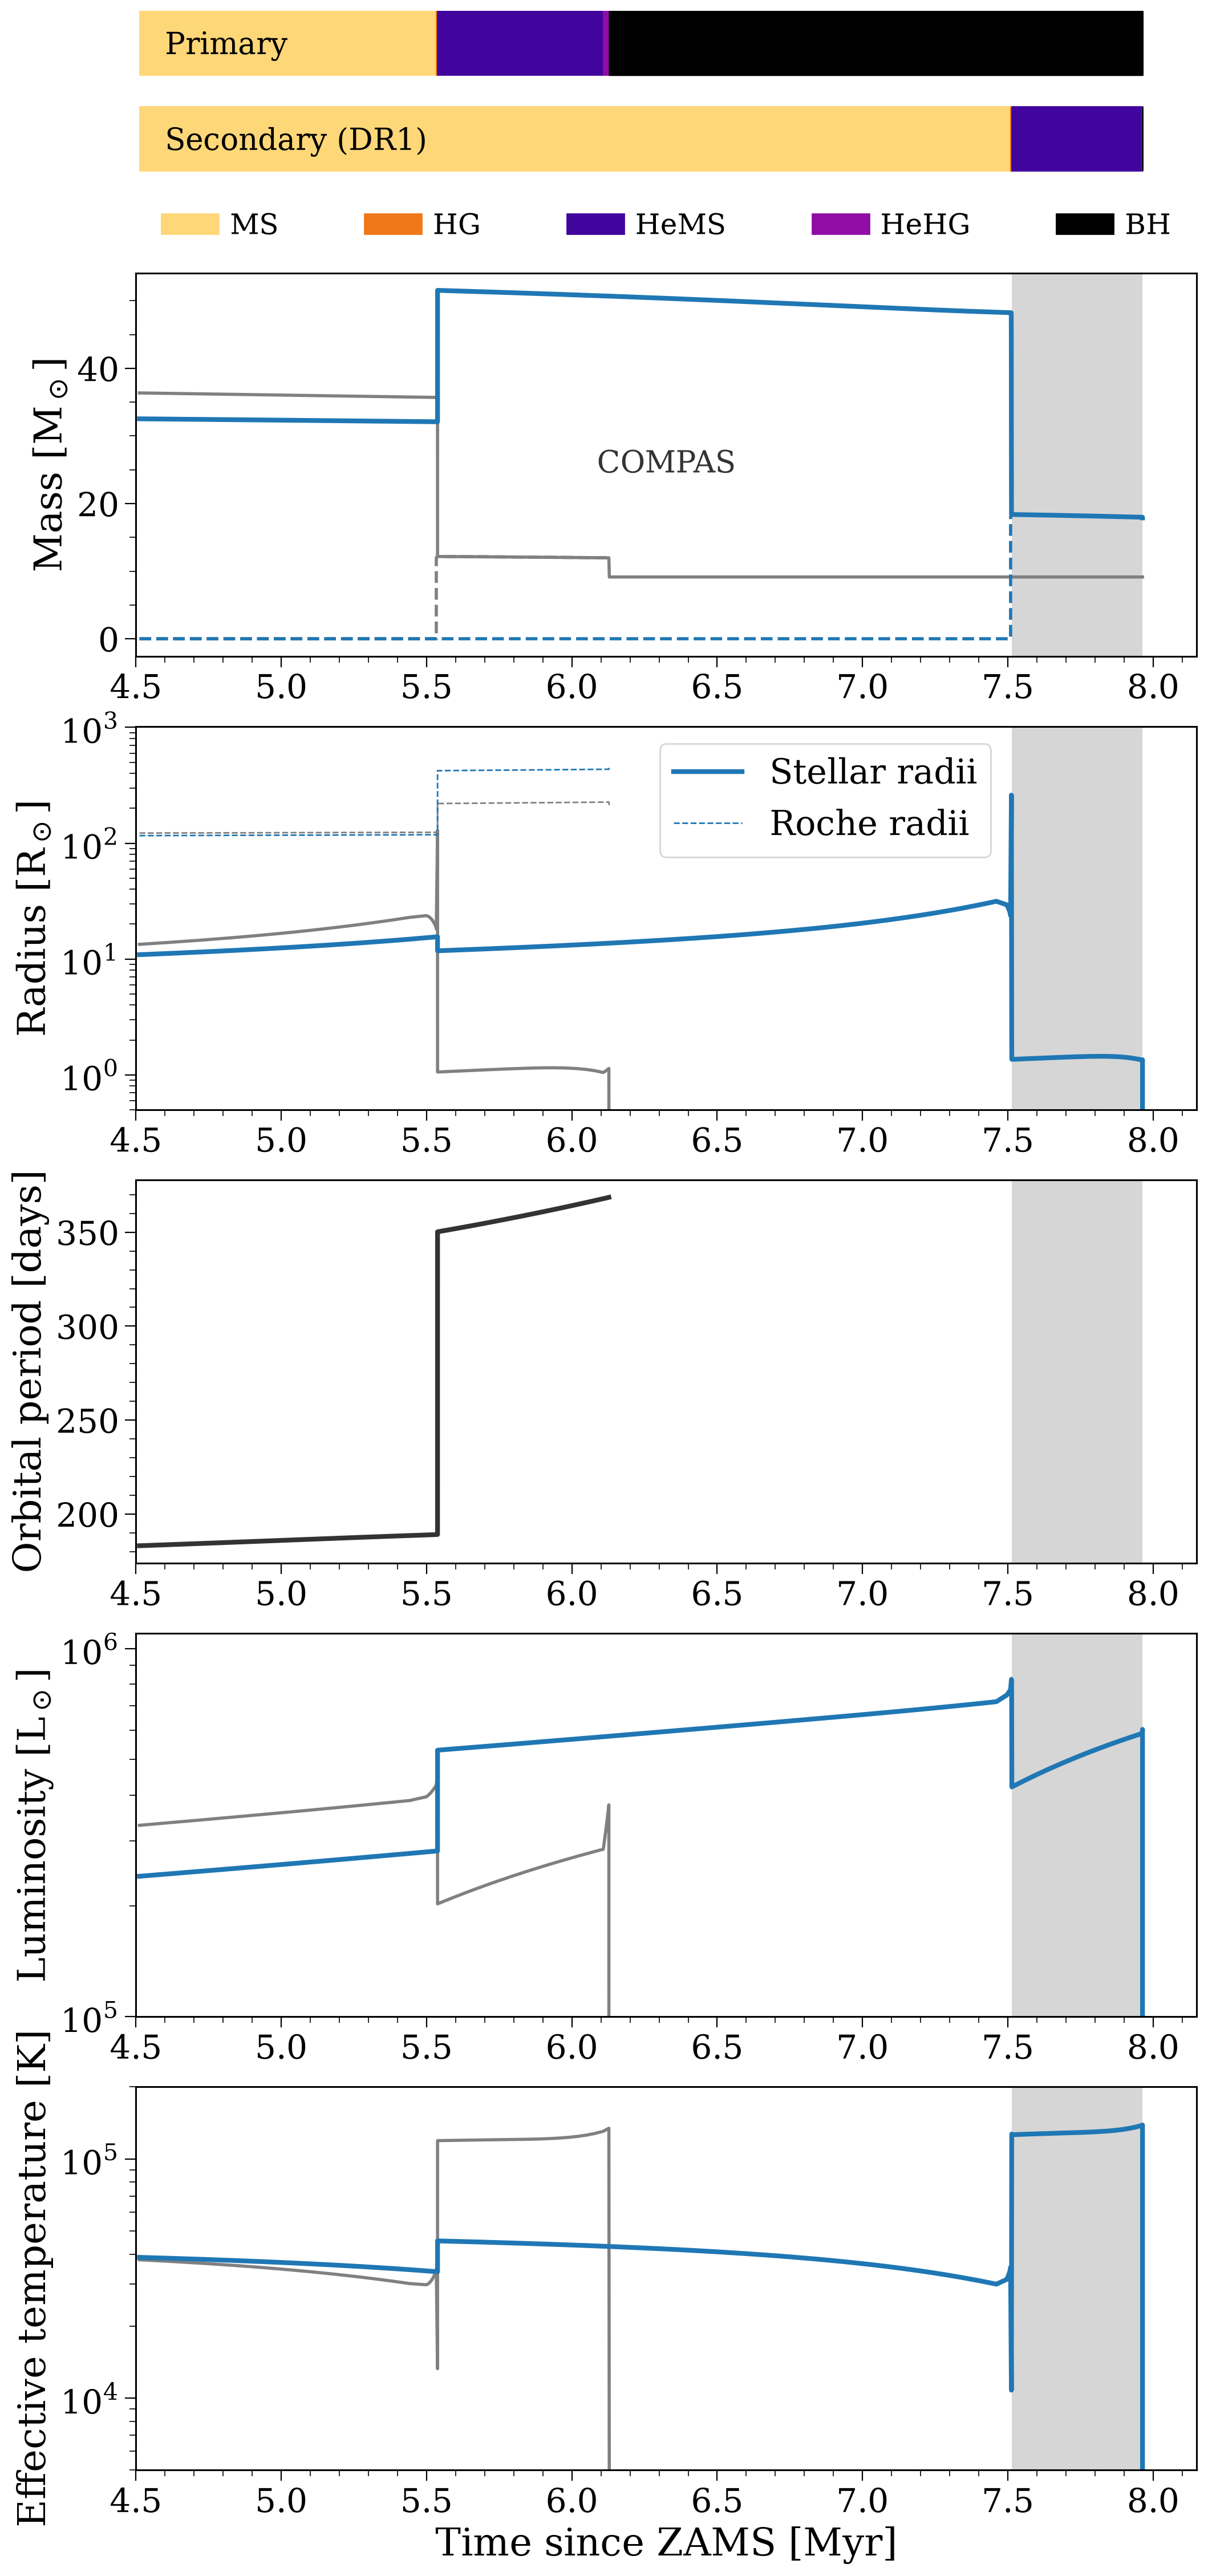

In [43]:
t_min = 4.5
t_max = 8.15

masked_bcm = compas_bcm[(compas_bcm["tphys"] > t_min) & (compas_bcm["tphys"] < t_max)]

primary_kwargs = {
    "color": "grey",
    "lw": 2
}
secondary_kwargs = {
    "color": "tab:blue",
    "lw": 3
}

dr1_rows = compas_bcm[compas_bcm["kstar_2"].isin([1, 7, 8]) & (compas_bcm["teff_2"] > 100_000)]

fig, axes = plt.subplots(6, 1, figsize=(12, 28), gridspec_kw={"height_ratios": [2, 4, 4, 4, 4, 4]})

axes[0].axis("off")

pos = axes[0].get_position()
new_pos = [pos.x0, pos.y0 - 0.02, pos.width, pos.height + 0.02]
axes[0].set_position(new_pos)

for j, k in enumerate(np.unique(masked_bcm["kstar_1"])):
    axes[0].fill_between(masked_bcm["tphys"][masked_bcm["kstar_1"] == k], 0.7, 0.9, color=kstar_colours[k])
for j, k in enumerate(np.unique(masked_bcm["kstar_2"])):
    axes[0].fill_between(masked_bcm["tphys"][masked_bcm["kstar_2"] == k], 0.4, 0.6, color=kstar_colours[k])

axes[0].annotate("Primary", xy=(4.6, 0.79), xycoords="data", fontsize=0.8*fs, ha="left", va="center")
axes[0].annotate("Secondary (DR1)", xy=(4.6, 0.49), xycoords="data", fontsize=0.8*fs, ha="left", va="center")

axes[0].set_ylim(0.1, 0.9)

k_type_all = np.unique(np.array([masked_bcm["kstar_1"], masked_bcm["kstar_2"]]))
patches = [
    mpl.patches.Patch(color=kstar_colours[k], label=kstar_labels[k]) for k in k_type_all
]
leg = axes[0].legend(handles=patches, mode="expand", ncol=len(k_type_all), frameon=False, fontsize=0.75*fs, handletextpad=0.4)

ax_mass = axes[1]
ax_rad = axes[2]
ax_porb = axes[3]
ax_lum = axes[4]
ax_teff = axes[5]

for suffix, kwargs in zip(["_1", "_2"], [primary_kwargs, secondary_kwargs]):
    
    ax_mass.plot(masked_bcm["tphys"], masked_bcm[f"mass{suffix}"], **kwargs)
    ax_mass.plot(masked_bcm["tphys"][masked_bcm[f"kstar{suffix}"] < 10],
                 (masked_bcm[f"massc_he_layer{suffix}"])[masked_bcm[f"kstar{suffix}"] < 10],
                 lw=2, color=kwargs["color"], linestyle='--')

    opposite = "_2" if suffix == "_1" else "_1"
    roche = cosmic.utils.calc_Roche_radius(masked_bcm[f"mass{suffix}"], masked_bcm[f"mass{opposite}"], masked_bcm["sep"] * (1.0 - masked_bcm["ecc"]))
    ax_rad.plot(masked_bcm["tphys"], masked_bcm[f"rad{suffix}"], **kwargs, label="Stellar radii" if suffix == "_2" else None)
    ax_rad.plot(masked_bcm["tphys"], roche, lw=1, color=kwargs["color"], linestyle="--", label="Roche radii" if suffix == "_2" else None)

    ax_lum.plot(masked_bcm["tphys"], masked_bcm[f"lum{suffix}"], **kwargs)

    ax_teff.plot(masked_bcm["tphys"], masked_bcm[f"teff{suffix}"], **kwargs)

ax_porb.plot(masked_bcm["tphys"][masked_bcm["porb"] > 0], masked_bcm["porb"][masked_bcm["porb"] > 0], color="#333", lw=3)

ax_mass.set_ylabel(r"Mass [M$_\odot$]")

ax_rad.legend(loc='upper center', fontsize=0.9*fs, frameon=True, bbox_to_anchor=(0.65, 1.0))
ax_rad.set(
    ylabel=r"Radius [R$_\odot$]",
    yscale="log",
    ylim=(5e-1, None)
)
ax_porb.set(
    ylabel=r"Orbital period [days]",
)

ax_lum.set(
    ylabel=r"Luminosity [L$_\odot$]",
    yscale="log",
    ylim=(1e5, 1.1e6)
)

ax_teff.set(
    ylabel=r"Effective temperature [K]",
    yscale="log",
    ylim=(5e3, 2e5)
)

for ax in axes:
    ax.set_xlim(t_min, t_max)

for ax in axes[1:]:
    ax.axvspan(dr1_rows["tphys"].min(), dr1_rows["tphys"].max(), color="#333", alpha=0.2, lw=0, label="DR1 window" if ax == axes[0] else None)

axes[-1].set_xlabel(r"Time since ZAMS [Myr]")

axes[1].annotate("COMPAS", xy=(0.5, 0.5), xycoords="axes fraction", fontsize=0.8*fs, ha="center", va="center", color="#333")

# plt.savefig(f"../figures/backpop_detailed_example.pdf", bbox_inches="tight", dpi=300)
plt.show()

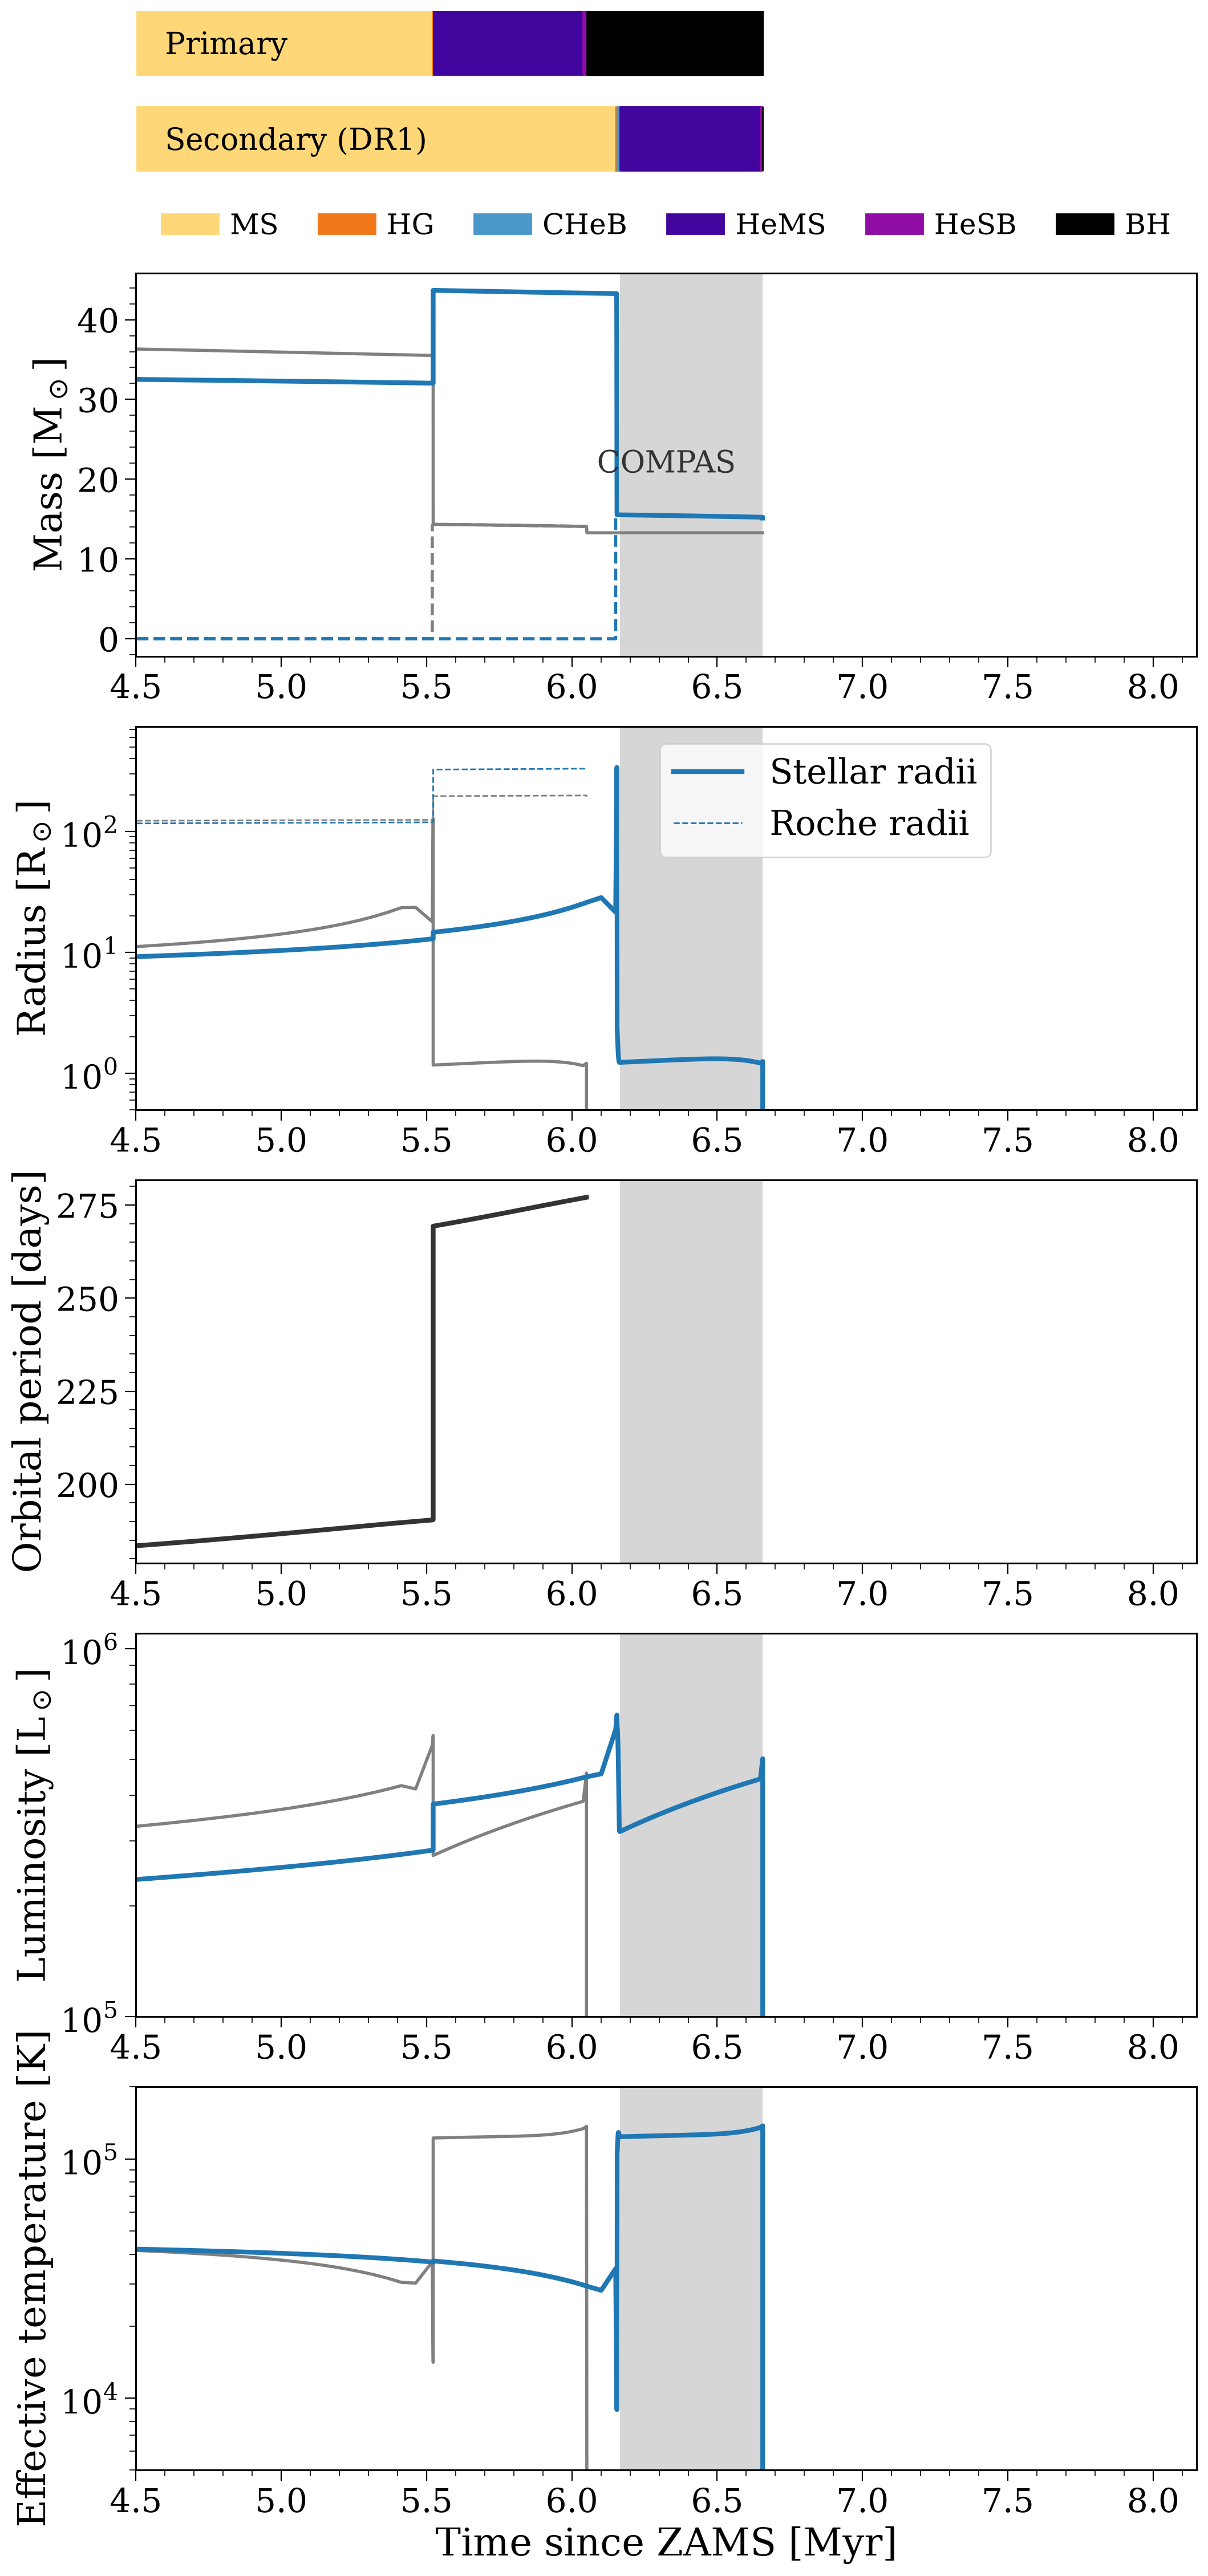

In [55]:
t_min = 4.5
t_max = 8.15

masked_bcm = compas_bcm[(compas_bcm["tphys"] > t_min) & (compas_bcm["tphys"] < t_max)]

primary_kwargs = {
    "color": "grey",
    "lw": 2
}
secondary_kwargs = {
    "color": "tab:blue",
    "lw": 3
}

dr1_rows = compas_bcm[compas_bcm["kstar_2"].isin([1, 7, 8]) & (compas_bcm["teff_2"] > 100_000)]

fig, axes = plt.subplots(6, 1, figsize=(12, 28), gridspec_kw={"height_ratios": [2, 4, 4, 4, 4, 4]})

axes[0].axis("off")

pos = axes[0].get_position()
new_pos = [pos.x0, pos.y0 - 0.02, pos.width, pos.height + 0.02]
axes[0].set_position(new_pos)

for j, k in enumerate(np.unique(masked_bcm["kstar_1"])):
    axes[0].fill_between(masked_bcm["tphys"][masked_bcm["kstar_1"] == k], 0.7, 0.9, color=kstar_colours[k])
for j, k in enumerate(np.unique(masked_bcm["kstar_2"])):
    axes[0].fill_between(masked_bcm["tphys"][masked_bcm["kstar_2"] == k], 0.4, 0.6, color=kstar_colours[k])

axes[0].annotate("Primary", xy=(4.6, 0.79), xycoords="data", fontsize=0.8*fs, ha="left", va="center")
axes[0].annotate("Secondary (DR1)", xy=(4.6, 0.49), xycoords="data", fontsize=0.8*fs, ha="left", va="center")

axes[0].set_ylim(0.1, 0.9)

k_type_all = np.unique(np.array([masked_bcm["kstar_1"], masked_bcm["kstar_2"]]))
patches = [
    mpl.patches.Patch(color=kstar_colours[k], label=kstar_labels[k]) for k in k_type_all
]
leg = axes[0].legend(handles=patches, mode="expand", ncol=len(k_type_all), frameon=False, fontsize=0.75*fs, handletextpad=0.4)

ax_mass = axes[1]
ax_rad = axes[2]
ax_porb = axes[3]
ax_lum = axes[4]
ax_teff = axes[5]

for suffix, kwargs in zip(["_1", "_2"], [primary_kwargs, secondary_kwargs]):
    
    ax_mass.plot(masked_bcm["tphys"], masked_bcm[f"mass{suffix}"], **kwargs)
    ax_mass.plot(masked_bcm["tphys"][masked_bcm[f"kstar{suffix}"] < 10],
                 (masked_bcm[f"massc_he_layer{suffix}"])[masked_bcm[f"kstar{suffix}"] < 10],
                 lw=2, color=kwargs["color"], linestyle='--')

    opposite = "_2" if suffix == "_1" else "_1"
    roche = cosmic.utils.calc_Roche_radius(masked_bcm[f"mass{suffix}"], masked_bcm[f"mass{opposite}"], masked_bcm["sep"] * (1.0 - masked_bcm["ecc"]))
    ax_rad.plot(masked_bcm["tphys"], masked_bcm[f"rad{suffix}"], **kwargs, label="Stellar radii" if suffix == "_2" else None)
    ax_rad.plot(masked_bcm["tphys"], roche, lw=1, color=kwargs["color"], linestyle="--", label="Roche radii" if suffix == "_2" else None)

    ax_lum.plot(masked_bcm["tphys"], masked_bcm[f"lum{suffix}"], **kwargs)

    ax_teff.plot(masked_bcm["tphys"], masked_bcm[f"teff{suffix}"], **kwargs)

ax_porb.plot(masked_bcm["tphys"][masked_bcm["porb"] > 0], masked_bcm["porb"][masked_bcm["porb"] > 0], color="#333", lw=3)

ax_mass.set_ylabel(r"Mass [M$_\odot$]")

ax_rad.legend(loc='upper center', fontsize=0.9*fs, frameon=True, bbox_to_anchor=(0.65, 1.0))
ax_rad.set(
    ylabel=r"Radius [R$_\odot$]",
    yscale="log",
    ylim=(5e-1, None)
)
ax_porb.set(
    ylabel=r"Orbital period [days]",
)

ax_lum.set(
    ylabel=r"Luminosity [L$_\odot$]",
    yscale="log",
    ylim=(1e5, 1.1e6)
)

ax_teff.set(
    ylabel=r"Effective temperature [K]",
    yscale="log",
    ylim=(5e3, 2e5)
)

for ax in axes:
    ax.set_xlim(t_min, t_max)

for ax in axes[1:]:
    ax.axvspan(dr1_rows["tphys"].min(), dr1_rows["tphys"].max(), color="#333", alpha=0.2, lw=0, label="DR1 window" if ax == axes[0] else None)

axes[-1].set_xlabel(r"Time since ZAMS [Myr]")

axes[1].annotate("COMPAS", xy=(0.5, 0.5), xycoords="axes fraction", fontsize=0.8*fs, ha="center", va="center", color="#333")

# plt.savefig(f"../figures/backpop_detailed_example.pdf", bbox_inches="tight", dpi=300)
plt.show()

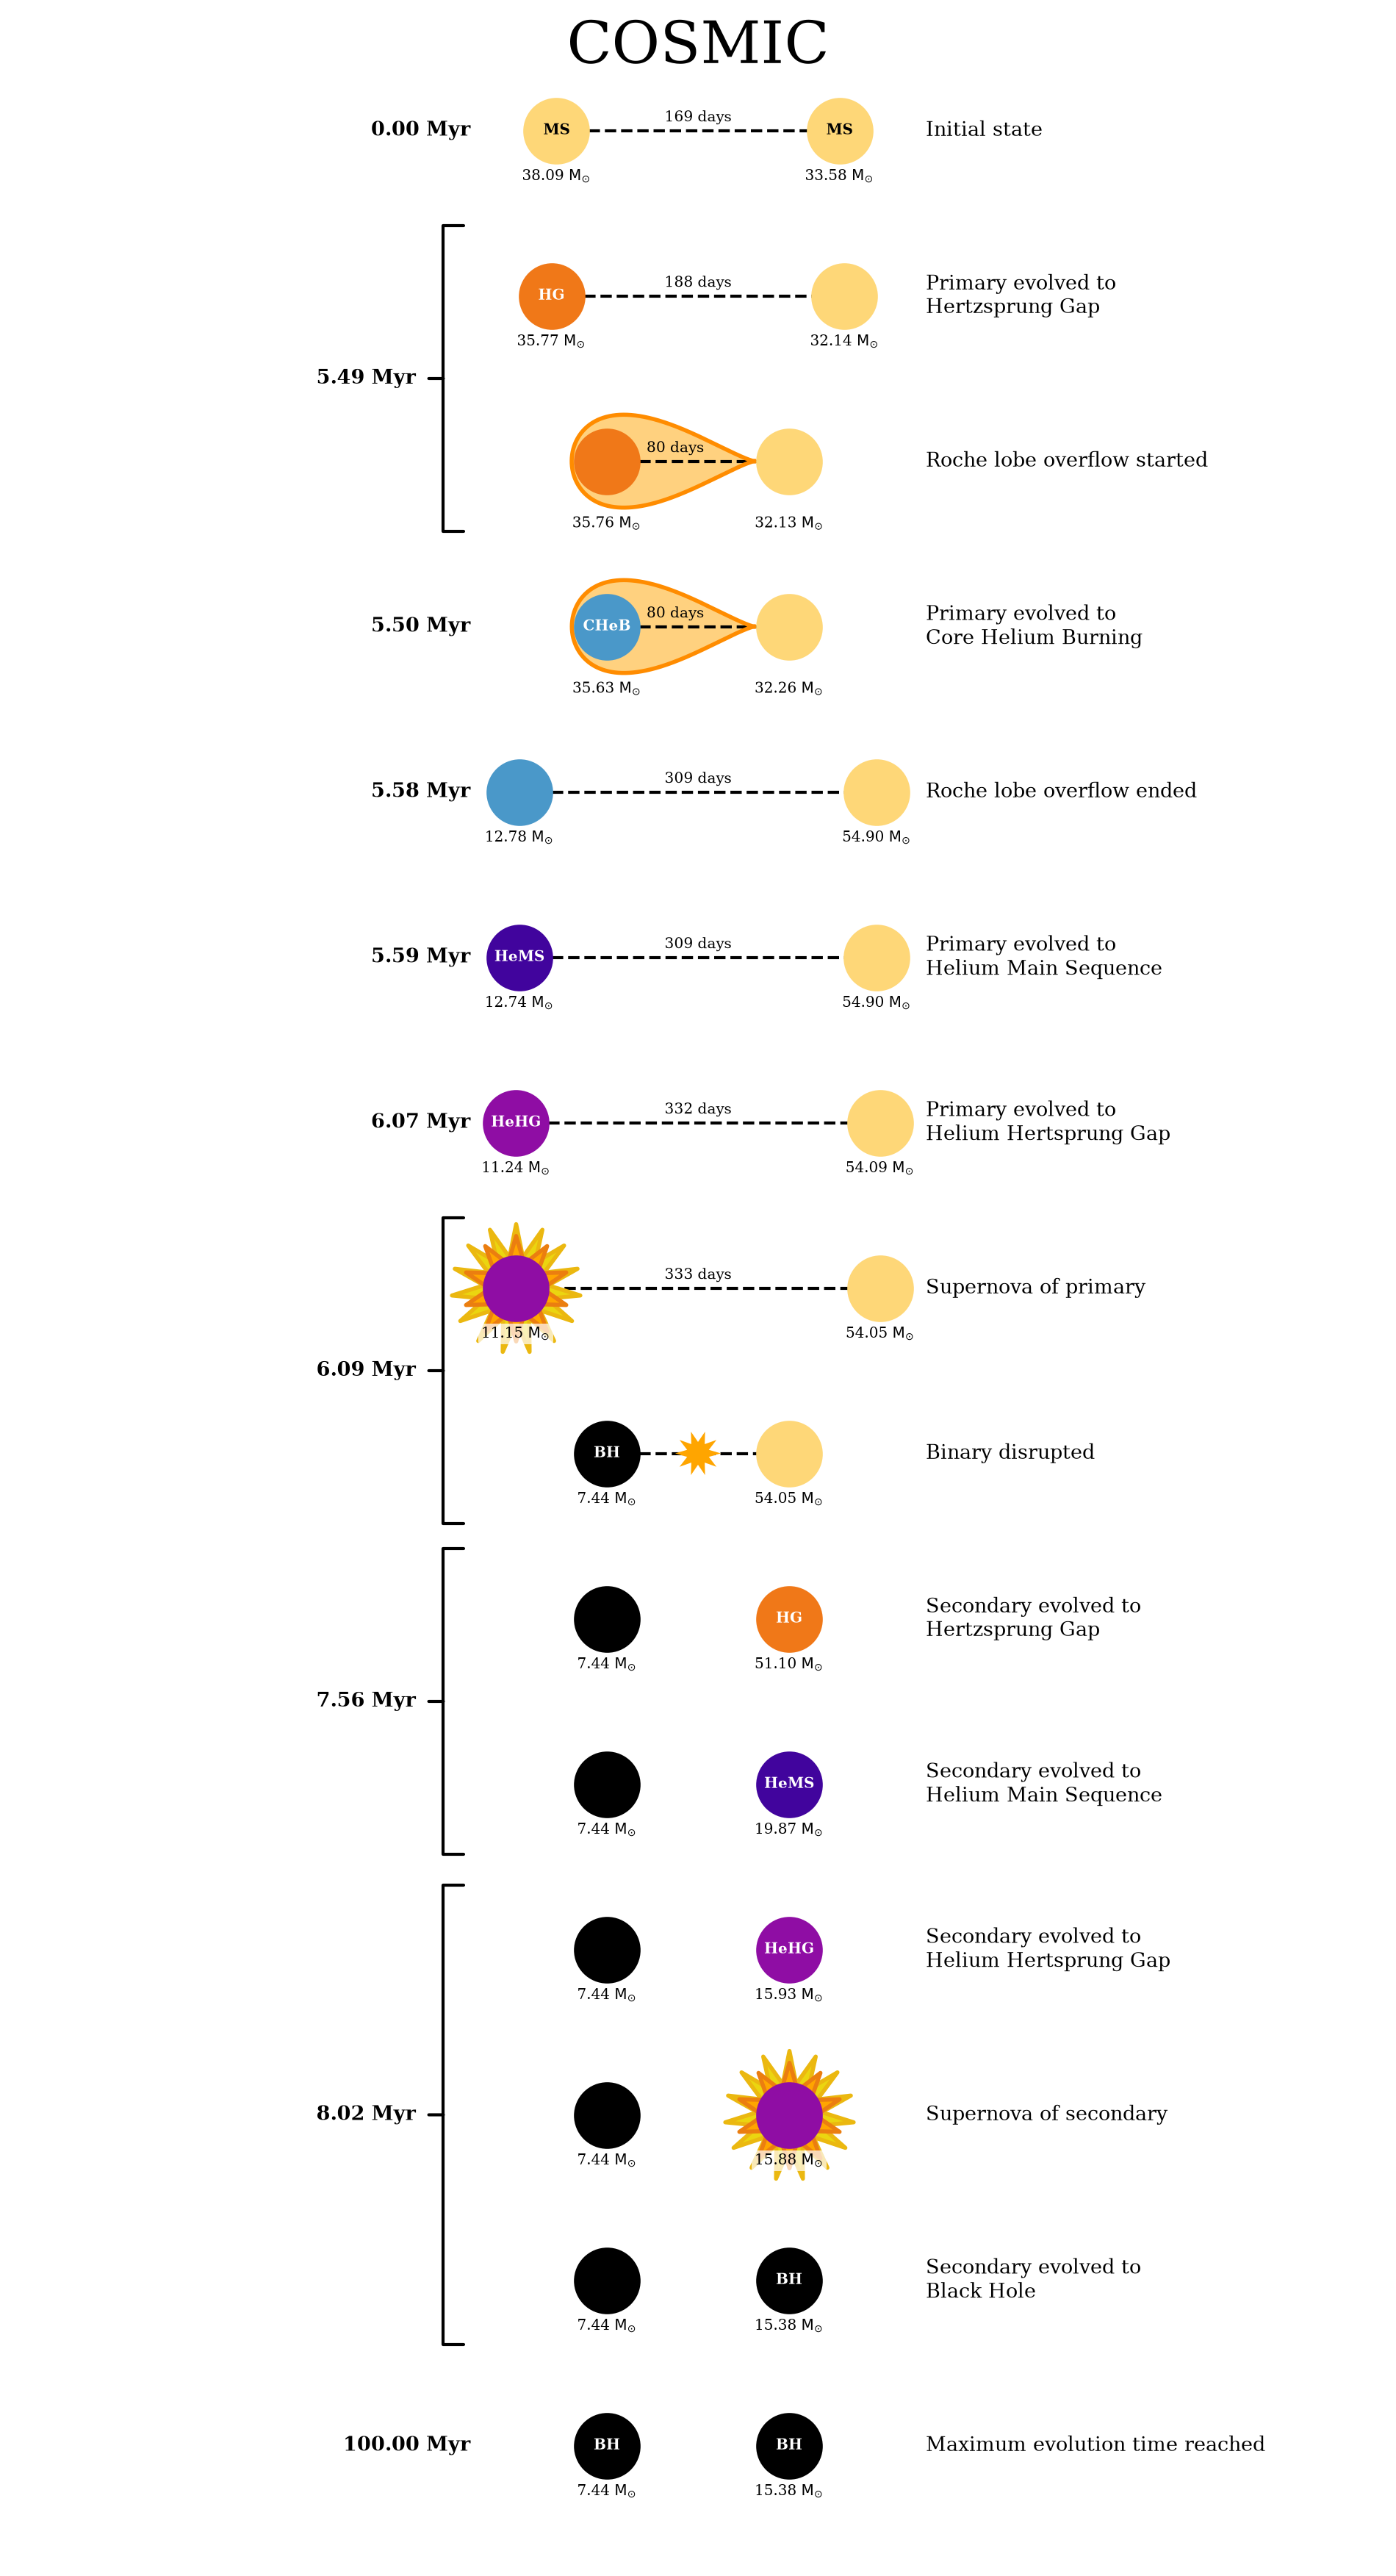

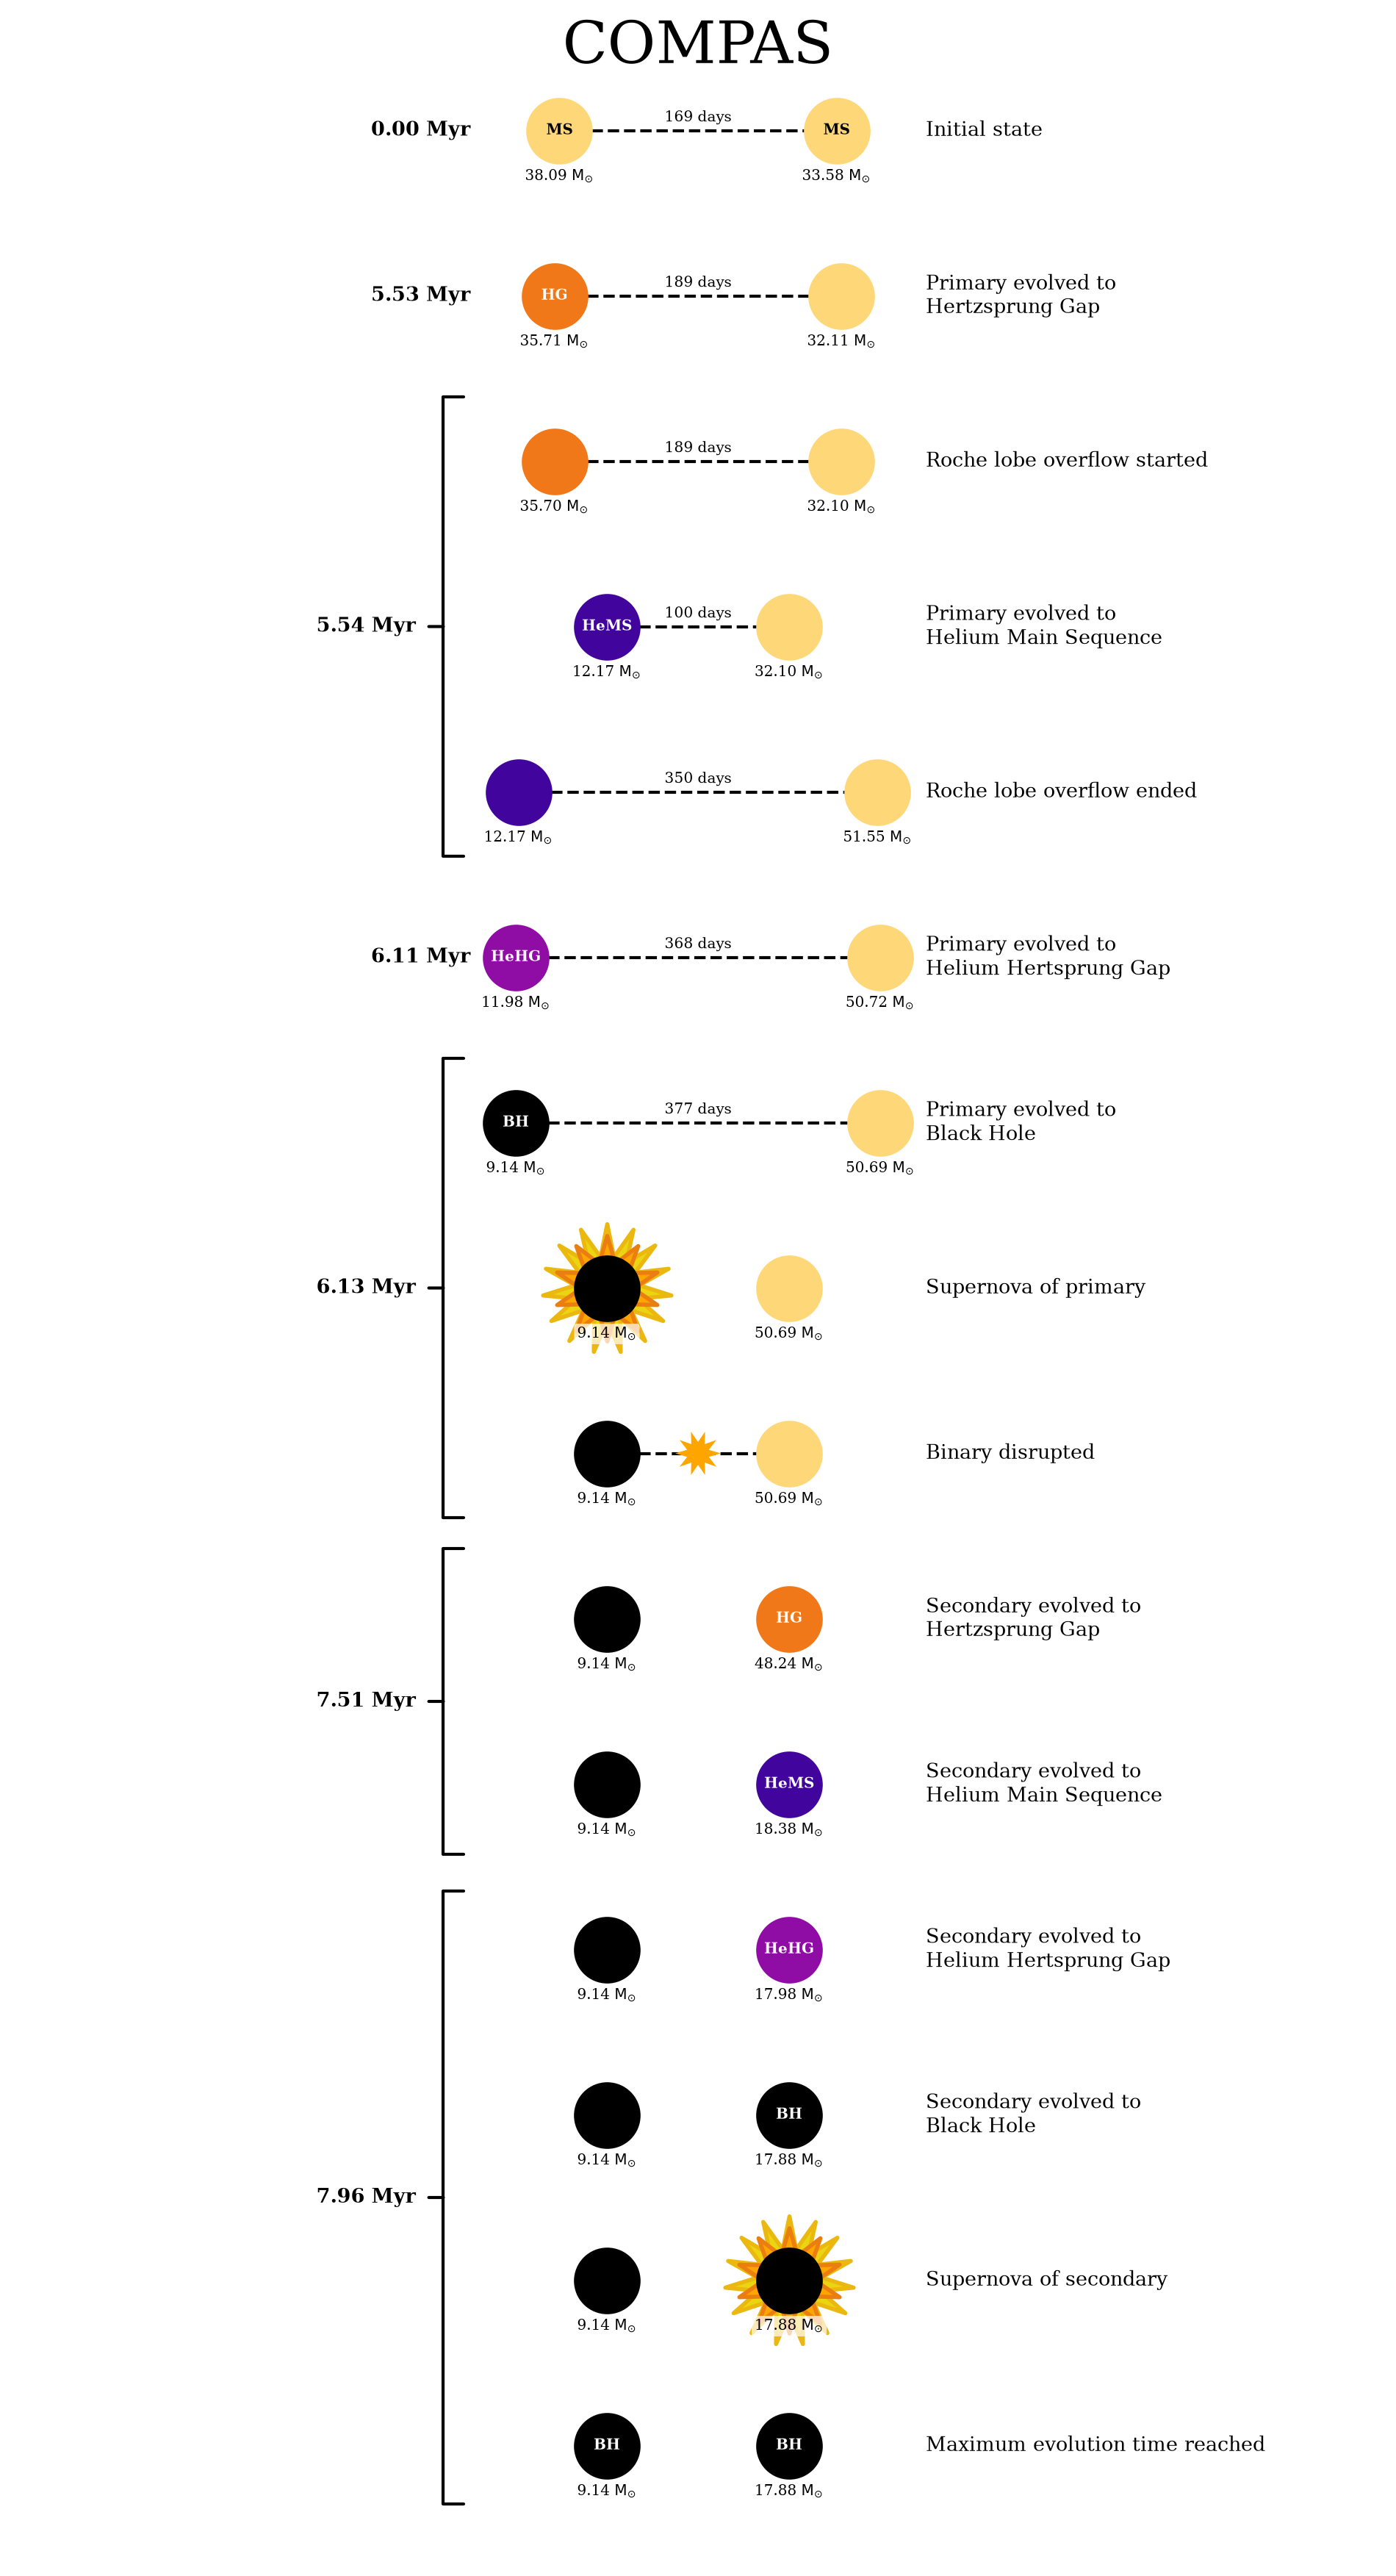

In [14]:
for bpp, title in zip([p.bpp.loc[example], get_bpp("../compas-runs/COMPAS_Output/COMPAS_Output.h5")], ["COSMIC", "COMPAS"]):
    cogsworth.plot.plot_cartoon_evolution(bpp, example, plot_title=title)

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,porb,ecc,RRLO_1,RRLO_2,evol_type,aj_1,aj_2,tms_1,tms_2,massc_he_layer_1,massc_he_layer_2,massc_co_layer_1,massc_co_layer_2,rad_1,rad_2,mass0_1,mass0_2,lum_1,lum_2,teff_1,teff_2,radc_1,radc_2,menv_1,menv_2,renv_1,renv_2,omega_spin_1,omega_spin_2,B_1,B_2,bacc_1,bacc_2,tacc_1,tacc_2,epoch_1,epoch_2,bhspin_1,bhspin_2,bin_num
35484,0.000000,38.088645,33.576042,1.0,1.0,534.747906,169.294635,0.434257,0.061610,0.060516,1.0,0.000000,0.000000,5.389140e+00,5.929380e+00,0.000000,0.000000,0.000000,0.000000,7.266984,6.738354,38.088645,33.576042,1.928268e+05,1.455599e+05,45069.667914,43626.781733,0.000000,0.000000,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,1.410306e+03,1.527751e+03,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,35484
35484,5.488392,35.766735,32.135431,2.0,1.0,563.684196,188.227959,0.434041,0.156757,0.139222,2.0,5.644743,5.609316,5.644743e+00,6.144932e+00,12.036891,0.000000,0.000000,0.000000,19.414661,16.419740,35.766735,32.135431,4.280038e+05,2.829997e+05,33656.319519,33001.446339,1.049741,0.000000,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,1.803976e+02,1.817700e+02,0.0,0.0,0.0,0.0,0.0,0.0,-0.156352,-0.120925,0.0,0.0,35484
35484,5.492060,35.760886,32.134227,2.0,1.0,319.051060,80.157320,0.000000,1.000925,0.139479,3.0,5.648412,5.613159,5.644743e+00,6.145122e+00,12.170019,0.000000,0.000000,0.000000,123.973917,16.452045,35.766735,32.134227,4.533739e+05,2.831771e+05,13511.967151,32974.193842,1.056845,0.000000,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,2.862958e+01,2.862958e+01,0.0,0.0,0.0,0.0,0.0,0.0,-0.156352,-0.121099,0.0,0.0,35484
35484,5.495025,35.633069,32.256890,4.0,1.0,318.523921,79.961782,0.000000,4.492680,0.138521,2.0,5.651377,5.577098,5.644743e+00,6.125771e+00,12.277608,0.000000,0.000000,0.000000,554.619241,16.340056,35.766735,32.256890,4.749719e+05,2.845157e+05,6463.073966,33126.030485,1.062563,0.000000,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,2.048010e+01,1.389242e+02,0.0,0.0,0.0,0.0,0.0,0.0,-0.156352,-0.082074,0.0,0.0,35484
35484,5.578120,12.784610,54.896142,4.0,1.0,784.108851,309.317227,0.000000,0.856928,0.032020,4.0,5.734472,2.374347,5.644743e+00,4.321070e+00,12.688015,0.000000,0.000000,0.000000,176.375409,12.743880,35.766735,54.896142,4.843835e+05,5.930481e+05,11517.227123,45070.384541,1.109210,0.000000,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,4.238543e-02,3.221669e+03,0.0,0.0,0.0,0.0,0.0,0.0,-0.156352,3.203773,0.0,0.0,35484
35484,5.588169,12.737632,54.898414,7.0,1.0,784.119740,309.425880,0.000000,0.005422,0.032078,2.0,0.090752,2.384347,5.516795e-01,4.320981e+00,11.246275,0.000000,1.491357,0.000000,1.114830,12.775173,12.737632,54.898414,2.369208e+05,5.942784e+05,121147.975481,45038.476157,0.000000,0.000000,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,2.247816e-01,3.197744e+03,0.0,0.0,0.0,0.0,0.0,0.0,5.497416,3.203822,0.0,0.0,35484
35484,6.066789,11.238279,54.090450,8.0,1.0,811.780128,331.648225,0.000000,0.004873,0.034398,2.0,0.597173,2.882666,5.971721e-01,4.353331e+00,3.417706,0.000000,7.820573,0.000000,1.006432,14.449622,11.238279,54.090450,2.521321e+05,6.373289e+05,129504.362653,43095.534219,0.000070,0.000000,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,1.928265e+01,2.223375e+03,0.0,0.0,0.0,0.0,0.0,0.0,5.469616,3.184123,0.0,0.0,35484
35484,6.088672,11.149858,54.050127,8.0,1.0,813.381502,332.958305,0.000000,0.005349,0.034513,15.0,0.618709,2.905279,5.971721e-01,4.354952e+00,2.812668,0.000000,8.337190,0.000000,1.104668,14.542803,11.238279,54.050127,3.451663e+05,6.393691e+05,133709.032468,42991.584789,0.000070,0.000000,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,4.066398e+09,2.182287e+03,0.0,0.0,0.0,0.0,0.0,0.0,5.469616,3.183028,0.0,0.0,35484
35484,6.088672,7.444550,54.050127,14.0,1.0,-1.000000,-1.000000,-1.000000,0.000000,-2.000000,11.0,0.618709,2.905279,5.971721e-01,4.354952e+00,2.812668,0.000000,8.337190,0.000000,1.104668,14.542803,11.238279,54.050127,3.451663e+05,6.393691e+05,133709.032468,42991.584

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,ecc,rad_1,rad_2,bin_num,evol_type,RRLO_1,RRLO_2,porb
35484,0.000000,38.088645,33.576042,1,1,534.942527,0.434257,7.027958,6.523531,35484,1,3.569505e-02,0.031278,169.297832
35484,5.533540,35.710265,32.105304,2,1,565.305104,0.434257,18.161988,15.520485,35484,2,8.689165e-02,0.070730,189.061442
35484,5.537690,35.700589,32.103463,2,1,565.401127,0.434257,128.331981,15.554476,35484,3,6.138387e-01,0.070876,189.125676
35484,5.537775,12.169730,32.103463,7,1,319.871694,0.000000,1.056830,15.554476,35484,2,7.110534e-03,0.162706,99.594787
35484,5.537775,12.169730,51.546210,7,1,835.109657,0.000000,1.056830,11.774879,35484,4,2.499052e-03,0.053515,350.214825
35484,6.108074,11.980590,50.724245,8,1,858.344909,0.000000,1.046727,13.608679,35484,2,2.408329e-03,0.060169,367.862529
35484,6.127321,9.136920,50.693299,14,1,859.251753,0.000000,0.000039,13.688499,35484,2,8.512397e-08,0.065135,377.193031
35484,6.127321,9.136920,50.690803,14,1,-1.000000,-1.000000,0.000039,13.688048,35484,15,0.000000e+00,0.000000,-1.000000
35484,6.127321,9.136920,50.690803,14,1,-1.000000,-1.000000,0.000039,13.688048,35484,11,0.000000e+00,0.000000,-1.000000
35484,7.509488,9.136920,48.239360,14,2,-1.000000,-1.000000,0.000039,23.648561,35484,2,0.000000e+00,0.000000,-1.000000
